In [38]:
# conda activate anndata

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [55]:
# Load cell metadata and latent space
adata = ad.read_h5ad("data/yao_2021_ACA_MOp_VISp_STAR_model/yao_2021_ACA_MOp_VISp_STAR_gene_counts_scVI.h5ad")

# Load single-cell PSI data
sdata = ad.read_h5ad("data/yao_2021_ACA_MOp_VISp_STAR_SJ_counts_PSI_annotated.h5ad")

In [ ]:
sum(~(adata.obs_names == sdata.obs_names))

## Choose data source

In [ ]:
# data_source = "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_Claude_marker_genes_enrichments_ctype_abundance_PSI_vs_exon_corr"
# corr_df = pd.read_csv(f"data/corrs/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_Claude_marker_genes_enrichments_ctype_abundance_PSI_vs_exon_corr.csv", index_col=0)

In [88]:
data_source = "yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments_PSI_vs_exon_corr"
corr_df = pd.read_csv(f"data/corrs/yao_2021_ACA_MOp_VISp_STAR_SyntheticDataset1_10pcntCells_20SD_200samples_mergeParam0.95_subsetCutoff825.95_Modules_yao_2021_ACA_MOp_VISp_STAR_donor_subclass_label_pseudobulk_pairwise_DE_genes_strictFALSE_logFC3_nSignif21_enrichments_PSI_vs_exon_corr.csv", index_col=0)

In [89]:
ctypes = corr_df.columns[1:]
gene_names_df = corr_df['Gene']

In [90]:
ctypes

Index(['Pvalb', 'L2_3_IT_CTX', 'L6b_CTX', 'Lamp5', 'L5_PT_CTX', 'Sncg',
       'L5_6_NP_CTX', 'Sst_Chodl', 'Meis2', 'Oligo', 'Car3', 'VLMC',
       'SMC-Peri', 'Astro', 'Endo', 'Micro-PVM'],
      dtype='object')

## Add PSIs to metadata

In [70]:
psi_df = pd.DataFrame(
    sdata.X, index=sdata.obs_names, columns=sdata.var_names
)

adata_psi = adata.copy()
adata_psi.obs = adata_psi.obs.join(psi_df)

## Prep UMAP

In [60]:
sc.pp.neighbors(adata, use_rep="scVI")
sc.tl.umap(adata, min_dist=0.3)

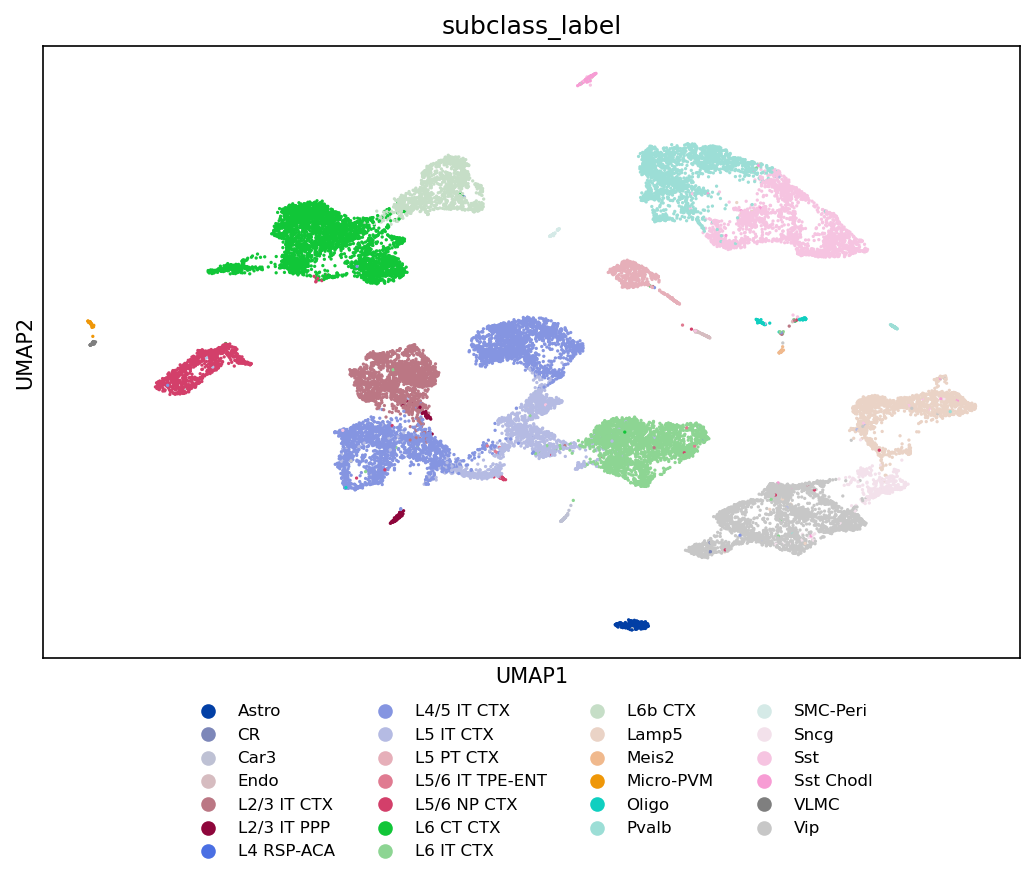

In [13]:
# Or for legend below:
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
sc.pl.umap(adata, color="subclass_label", size=10, ax=ax, show=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), 
          ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Plot

In [97]:
ctype = "Oligo"

corr_df.sort_values(ctype, ascending=ascending)[:15]

,Gene,Pvalb,L2_3_IT_CTX,L6b_CTX,Lamp5,L5_PT_CTX,Sncg,L5_6_NP_CTX,Sst_Chodl,Meis2,Oligo,Car3,VLMC,SMC-Peri,Astro,Endo,Micro-PVM
ENSMUSG00000028399_ProteinCoding_7,Ptprd,0.051531,-0.013861,0.127184,0.079029,-0.069035,0.051103,-0.032315,-0.009070,-0.118892,-0.931772,-0.018622,-0.019285,-0.004048,0.076688,-0.053397,-0.107549
ENSMUSG00000024044_ProteinCoding_3,Epb41l3,0.091414,0.014940,0.128188,0.041311,-0.062916,0.042289,-0.047645,0.052787,-0.014463,-0.929186,0.025823,-0.140895,-0.069949,0.088569,-0.064866,-0.161467
ENSMUSG00000055717_ProteinCoding_1,Slain1,0.024496,0.050238,0.112031,0.035257,-0.090092,-0.045876,0.011104,0.057808,-0.047269,-0.920225,-0.022306,0.009313,-0.035082,0.055896,-0.091939,-0.090603
ENSMUSG00000038608_ProteinCoding_4,Dock10,-0.002603,0.011820,0.078521,0.127322,-0.156845,0.026420,-0.029043,0.042979,-0.075846,-0.887948,-0.062708,0.008741,-0.027238,0.030464,-0.079172,0.005621
ENSMUSG00000015149_ProteinCoding_1,Sirt2,0.041604,-0.029559,0.229742,0.096316,-0.027644,0.031524,-0.041111,0.034746,-0.108703,-0.885744,0.008222,-0.008730,-0.094165,0.095181,-0.151460,-0.194246
ENSMUSG00000034751_ProteinCoding_5,Mast4,0.017936,0.017638,0.170498,0.071106,-0.117230,0.014715,0.020554,0.028212,-0.133096,-0.881189,0.048906,-0.054366,-0.011796,0.044995,-0.096846,-0.088216
ENSMUSG00000041020_ProteinCoding_1,Map7d2,0.069737,0.064995,0.114788,0.102543,-0.110477,0.008721,-0.000913,0.078768,-0.114576,-0.869340,0.013929,0.011199,-0.257619,-0.046603,-0.072069,-0.080248
ENSMUSG00000024381_ProteinCoding_4,Bin1,0.099734,-0.012917,0.210754,0.023799,-0.013866,0.114506,-0.046804,0.065113,0.031844,-0.843279,0.002167,-0.089429,-0.093320,0.087777,-0.140828,-0.554336
ENSMUSG00000030701_ProteinCoding_1,Plekhb1,0.062281,-0.065077,0.113639,0.102914,-0.116063,0.104587,0.058552,0.001905,-0.065353,-0.839387,0.023715,0.050263,-0.001525,0.086213,-0.009837,-0.147868
ENSMUSG00000024381_ProteinCoding_1,Bin1,0.093991,0.005446,0.229860,0.032624,-0.018225,0.119984,-0.045123,0.074917,0.047362,-0.828195,0.000276,-0.072189,-0.144492,0.080574,-0.121620,-0.582089


In [99]:
sdata.var.loc["ENSMUSG00000028399_ProteinCoding_7"]

exon_start    76056793
exon_end      76056810
Name: ENSMUSG00000028399_ProteinCoding_7, dtype: int64

In [ ]:
75785198

In [94]:
outdir = f"figures/scRNA-seq/{data_source}"

In [95]:
ascending = True

In [96]:
os.makedirs(outdir, exist_ok=True)

def _safe(name):
    import re
    # simple filename sanitizer
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(name))

for ctype in ctypes:
    print(ctype)
    top_genes = corr_df.sort_values(ctype, ascending=ascending)[:15]
    pdf_path = f"{outdir}/{_safe(ctype)}_ascending{ascending}.pdf"
    with PdfPages(pdf_path) as pdf:
        for idx, row in top_genes.iterrows():
            print(idx)
            gene = row['Gene']
            exon = "_".join(row.name.split("_")[-2:])
            exon_len = sdata.var.loc[row.name]['exon_end'] - sdata.var.loc[row.name]['exon_start'] + 1
            title = [f"{ctype}\n{gene} {exon}", f"{gene} {exon}\nCor: {np.round(row[ctype], 3)}\nExon length: {exon_len}"]
            axes = sc.pl.umap(adata_psi, title=title,
                              color=["subclass_label", row.name], size=10,
                              ncols=1, show=False, return_fig=False,
                              use_raw=True)
            for a in axes: 
                a.legend(loc="center left", bbox_to_anchor=(1.0, 0.5),
                        ncol=1, fontsize=8, frameon=False)
            fig = plt.gcf()
            fig.set_size_inches(10, 10)
            fig.set_dpi(150)
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Pvalb
ENSMUSG00000033419_ProteinCoding_4


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ENSMUSG00000052889_NMD_1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


...

ENSMUSG00000026458_ProteinCoding_1


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ENSMUSG00000005583_ProteinCoding_7


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ENSMUSG00000019960_ProteinCoding_1
